In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

In [26]:
import scienceplots

plt.style.use('science')
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage[T1]{fontenc} \usepackage{polski} \usepackage[utf8]{inputenc}'
})
figsize = (6, 3)
new_orange = '#ff5500'

#### Zadanie 1.
W ankiecie przedstawionej na poprzedniej liście pracownicy zostali poproszeni o wyrażenie opinii na temat skuteczności szkolenia "Efektywna komunikacja w zespole" zorganizowanego przez firmę. Wśród próbki 200 pracowników (losowanie proste ze zwracaniem) uzyskano wyniki:

- 14 pracowników - bardzo niezadowolonych,
- 17 pracowników - niezadowolonych,
- 40 pracowników - nie ma zdania,
- 100 pracowników - zadowolonych,
- 29 pracowników - bardzo zadowolonych.

Na podstawie danych wyznacz przedział ufności dla wektora prawdopodobieństw opisującego stopień zadowolenia ze szkolenia. Przyjmij poziom ufności 0.95.

In [27]:
n = 200
counts = np.array([14, 17, 40, 100, 29])
k = len(counts)
labels = [
    'Bardzo niezadowoleni',
    'Niezadowoleni',
    'Nie ma zdania',
    'Zadowoleni',
    'Bardzo zadowoleni'
]

p_hat = counts / n

alpha = 0.05
z_val = scipy.stats.norm.ppf(1 - alpha / (2 * k))

se = np.sqrt((p_hat * (1 - p_hat)) / n)
margin_of_error = z_val * se

ci_lower = np.maximum(0, p_hat - margin_of_error)
ci_upper = np.minimum(1, p_hat + margin_of_error)

df_results = pd.DataFrame({
    'Opinia': labels,
    'n_i': counts,
    'p_hat': p_hat,
    'Dolna granica (95%)': ci_lower.round(4),
    'Górna granica (95%)': ci_upper.round(4)
})

print("Tabela przedziałów ufności:")
print(df_results.to_string(index=False))

Tabela przedziałów ufności:
              Opinia  n_i  p_hat  Dolna granica (95%)  Górna granica (95%)
Bardzo niezadowoleni   14  0.070               0.0235               0.1165
       Niezadowoleni   17  0.085               0.0342               0.1358
       Nie ma zdania   40  0.200               0.1271               0.2729
          Zadowoleni  100  0.500               0.4089               0.5911
   Bardzo zadowoleni   29  0.145               0.0809               0.2091


## Zadanie 2
Napisz funkcję, która wyznacza wartość poziomu krytycznego w następujących testach:chi-kwadrat Pearsona chi-kwadrat największej wiarogodności służących do weryfikacji hipotezy $H_0:p=p_0$ przy hipotezie alternatywnej $H_0:p\neq p_0$ na podstawie obserwacji x wektora losowego X z rozkładu wielomianowego z parametrami n i p.Uwaga do raportu: W oryginalnym pliku z zadaniami w zapisie hipotezy alternatywnej pojawia się oczywista literówka ($H_0:p\neq p_0$ zamiast $H_1$ lub $H_A$). Warto to delikatnie sprostować w samym sprawozdaniu, używając poprawnego oznaczenia.

In [28]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

def p_value_multinomial(x, p0):
    # Konwersja list na wektory numpy dla ułatwienia obliczeń matematycznych
    x = np.array(x)
    p0 = np.array(p0)

    # 1. Walidacja danych wejściowych
    if len(x) != len(p0):
        raise ValueError("Błąd: Wektor obserwacji x i wektor prawdopodobieństw p0 muszą mieć taką samą długość.")

    # 2. Wyznaczenie parametrów
    n = np.sum(x)          # Całkowita liczba obserwacji
    k = len(x)             # Liczba kategoriis
    df = k - 1             # Liczba stopni swobody

    # Liczebności oczekiwane
    E = n * p0

    # 3. Statystyka i p-value: Chi-kwadrat Pearsona
    chi2_pearson = np.sum((x - E)**2 / E)
    # Metoda .sf() (survival function) to odpowiednik lower.tail=FALSE z R
    p_val_pearson = chi2.sf(chi2_pearson, df)

    # 4. Statystyka i p-value: Chi-kwadrat największej wiarogodności (G-test)
    # Maska logiczna zabezpieczająca przed błędem log(0)
    idx = x > 0
    chi2_lr = 2 * np.sum(x[idx] * np.log(x[idx] / E[idx]))
    p_val_lr = chi2.sf(chi2_lr, df)

    # 5. Formatowanie wyniku jako ramka danych Pandas
    wyniki = pd.DataFrame({
        'Statystyka': [chi2_pearson, chi2_lr],
        'p-value': [p_val_pearson, p_val_lr],
        'Stopnie swobody': [df, df]
    }, index=['Chi-kwadrat Pearsona', 'Iloraz wiarogodności (G-test)'])

    return wyniki

# --- Przykładowe użycie ---
obserwacje = [22, 28, 25, 25]
prawdopodobienstwa_H0 = [0.25, 0.25, 0.25, 0.25]

tabela_wynikow = p_value_multinomial(x=obserwacje, p0=prawdopodobienstwa_H0)
print(tabela_wynikow)

                               Statystyka   p-value  Stopnie swobody
Chi-kwadrat Pearsona             0.720000  0.868490                3
Iloraz wiarogodności (G-test)    0.721738  0.868079                3


### Zadanie 3


In [29]:
def p_value_multinomial(x, p0):
    x = np.array(x)
    p0 = np.array(p0)

    if len(x) != len(p0):
        raise ValueError("Błąd: Wektor obserwacji x i wektor prawdopodobieństw p0 muszą mieć taką samą długość.")

    n = np.sum(x)
    k = len(x)
    df = k - 1

    E = n * p0

    chi2_pearson = np.sum((x - E) ** 2 / E)
    p_val_pearson = scipy.stats.chi2.sf(chi2_pearson, df)

    idx = x > 0
    chi2_lr = 2 * np.sum(x[idx] * np.log(x[idx] / E[idx]))
    p_val_lr = scipy.stats.chi2.sf(chi2_lr, df)

    wyniki = pd.DataFrame({
        'Statystyka': [chi2_pearson, chi2_lr],
        'p-value': [p_val_pearson, p_val_lr],
        'Stopnie swobody': [df, df]
    }, index=['Chi-kwadrat Pearsona', 'Iloraz wiarogodności (G-test)'])

    return wyniki


df = pd.read_csv('ankieta2.csv', sep=';')

print("Dostępne działy w pliku:", df['DZIAŁ'].unique())

nazwa_dzialu = 'PD'
df_dzial = df[df['DZIAŁ'] == nazwa_dzialu]

mozliwe_odpowiedzi = [-2, -1, 0, 1, 2]

# value_counts() zlicza odpowiedzi, a reindex zapewnia, że braki zostaną uzupełnione 0.
zliczenia = df_dzial['PYT_1'].value_counts().reindex(mozliwe_odpowiedzi, fill_value=0).values

prawdopodobienstwa_H0 = [0.2, 0.2, 0.2, 0.2, 0.2]
alpha = 0.05

print(f"Analiza dla działu: {nazwa_dzialu}")
print(f"Liczebności odpowiedzi dla kategorii [-2, -1, 0, 1, 2]: {zliczenia}")
print("-" * 50)

wyniki_testu = p_value_multinomial(x=zliczenia, p0=prawdopodobienstwa_H0)
print(wyniki_testu)
print("-" * 50)

p_val = wyniki_testu.loc['Chi-kwadrat Pearsona', 'p-value']

print(f"Poziom istotności (alpha) = {alpha}")
print(f"Otrzymane p-value (Pearson) = {p_val:.4f}")

if p_val < alpha:
    print("Wniosek: Odrzucamy hipotezę zerową (H0).")
    print("Rozkład odpowiedzi NIE jest równomierny.")
else:
    print("Wniosek: Nie ma podstaw do odrzucenia hipotezy zerowej (H0).")
    print("Możemy przyjąć, że rozkład odpowiedzi jest równomierny.")

Dostępne działy w pliku: ['IT' 'PD' 'MK' 'HR']
Analiza dla działu: PD
Liczebności odpowiedzi dla kategorii [-2, -1, 0, 1, 2]: [ 9 10 17 51 11]
--------------------------------------------------
                               Statystyka       p-value  Stopnie swobody
Chi-kwadrat Pearsona            64.857143  2.757834e-13                4
Iloraz wiarogodności (G-test)   52.527114  1.070199e-10                4
--------------------------------------------------
Poziom istotności (alpha) = 0.05
Otrzymane p-value (Pearson) = 0.0000
Wniosek: Odrzucamy hipotezę zerową (H0).
Rozkład odpowiedzi NIE jest równomierny.


## Zadanie 4
Korzystając z testu Fishera, na poziomie istotności 0.05, zweryfikuj hipotezę, że zmienna PŁEĆ i zmienna CZY_KIER są niezależne. Czy na poziomie istotności 0.05 możemy wnioskować, że prawdopodobieństwo tego, że na stanowisku kierowniczym pracuje kobieta jest równe prawdopodobieństwu tego, że na stanowisku kierowniczym pracuje mężczyzna? Uzasadnij odpowiedź.

In [30]:
import pandas as pd
import scipy.stats as stats

# 1. Wczytanie danych z uwzględnieniem separatora średnika
df = pd.read_csv('ankieta2.csv', sep=';')

# Naprawa kodowania polskich znaków w nagłówkach
df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

# 2. Generowanie tablicy kontyngencji (tabeli krzyżowej 2x2)
tablica_krzyzowa = pd.crosstab(df['PŁEĆ'], df['CZY_KIER'])

print("--- Tablica kontyngencji ---")
print(tablica_krzyzowa)

# 3. Przeprowadzenie dokładnego testu Fishera
odds_ratio, p_value = stats.fisher_exact(tablica_krzyzowa)

print(f"\n--- Wyniki testu Fishera ---")
print(f"Iloraz szans (Odds Ratio): {odds_ratio:.4f}")
print(f"p-value: {p_value:.4f}")

# 4. Weryfikacja hipotezy statystycznej
alpha = 0.05
print("\n--- Konkluzja ---")
if p_value < alpha:
    print("Odrzucamy H0. Zmienne PŁEĆ i CZY_KIER są statystycznie zależne.")
else:
    print("Brak podstaw do odrzucenia H0. Zmienne PŁEĆ i CZY_KIER są statystycznie niezależne.")

--- Tablica kontyngencji ---
CZY_KIER  Nie  Tak
PŁEĆ              
K          63    8
M         110   19

--- Wyniki testu Fishera ---
Iloraz szans (Odds Ratio): 1.3602
p-value: 0.6659

--- Konkluzja ---
Brak podstaw do odrzucenia H0. Zmienne PŁEĆ i CZY_KIER są statystycznie niezależne.


# zadanie 6

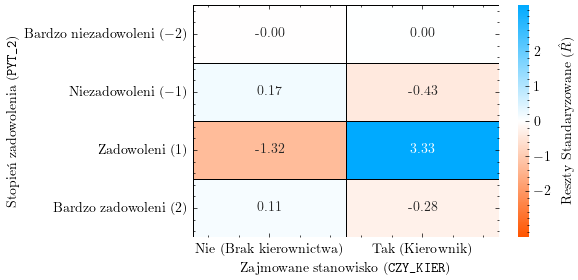

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import scienceplots

sns.reset_orig()

plt.style.use(['default', 'science'])
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage[T1]{fontenc} \usepackage{polski} \usepackage[utf8]{inputenc}'
})
figsize = (6, 3)
new_orange = '#ff5500'

data_counts = np.array([[64, 10], [18, 2], [0, 2], [91, 13]])
y_categories = [-2, -1, 1, 2]
x_categories = ['Nie', 'Tak']

y_labels = ['Bardzo niezadowoleni ($-2$)', 'Niezadowoleni ($-1$)',
            'Zadowoleni ($1$)', 'Bardzo zadowoleni ($2$)']
x_labels = ['Nie (Brak kierownictwa)', 'Tak (Kierownik)']

tablica_krzyzowa = pd.DataFrame(data_counts, index=y_categories, columns=x_categories)

stat, p_value, dof, expected = stats.chi2_contingency(tablica_krzyzowa)
residuals = (tablica_krzyzowa - expected) / np.sqrt(expected)
residuals.index = y_labels
residuals.columns = x_labels

fig, ax = plt.subplots(figsize=figsize)

inverse_orange = '#00aaff'
colors = [new_orange, 'white', inverse_orange]
cmap_res = mcolors.LinearSegmentedColormap.from_list('BlueOrange', colors, N=256)

vabs = np.abs(residuals.values).max()

sns.heatmap(residuals,
            annot=True,
            cmap=cmap_res,
            center=0,
            vmin=-vabs, vmax=vabs,
            fmt=".2f",
            linewidths=0.5,
            linecolor='black',
            annot_kws={'size': 10},
            cbar_kws={'label': r'Reszty Standaryzowane ($\hat{R}$)', 'ticks': [-2, -1, 0, 1, 2]},
            ax=ax)

ax.set_xlabel(r'Zajmowane stanowisko (\texttt{CZY\_KIER})')
ax.set_ylabel(r'Stopień zadowolenia (\texttt{PYT\_2})')

plt.tight_layout()

plt.savefig('wykres_asocjacyjny.pdf')
plt.show()

### zadanie 7

In [32]:
def lr_test_independence(observed_table):
    """
    Oblicza statystykę G oraz p-value dla testu niezależności opartego
    na ilorazie wiarogodności dla tablicy dwudzielczej.
    """
    O = np.array(observed_table)

    row_sums = O.sum(axis=1)
    col_sums = O.sum(axis=0)
    total = O.sum()

    E = np.outer(row_sums, col_sums) / total

    df = (O.shape[0] - 1) * (O.shape[1] - 1)

    mask = O > 0
    G = 2 * np.sum(O[mask] * np.log(O[mask] / E[mask]))

    p_value = scipy.stats.chi2.sf(G, df)

    return G, p_value, df


df = pd.read_csv('ankieta2.csv', sep=';')
df = df.rename(columns={'P£E∆': 'PŁEĆ', 'STAĮ': 'STAŻ', 'DZIA£': 'DZIAŁ'})

tablica_krzyzowa = pd.crosstab(df['PYT_2'], df['CZY_KIER'])

print("--- Tablica krzyżowa (Obserwacje) ---")
print(tablica_krzyzowa)
print("-" * 50)

G_stat, p_val_lr, stopnie_swobody = lr_test_independence(tablica_krzyzowa)

print("--- Wyniki Testu Ilorazu Wiarogodności (G-test) ---")
print(f"Statystyka G: {G_stat:.4f}")
print(f"Stopnie swobody: {stopnie_swobody}")
print(f"p-value:      {p_val_lr:.4f}")
print("-" * 50)

alpha = 0.05
if p_val_lr < alpha:
    print("Wniosek: Odrzucamy H0.")
    print("Zmienne PYT_2 i CZY_KIER są ZALEŻNE.")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0.")
    print("Zmienne PYT_2 i CZY_KIER są NIEZALEŻNE.")


--- Tablica krzyżowa (Obserwacje) ---
CZY_KIER  Nie  Tak
PYT_2             
-2         64   10
-1         18    2
 1          0    2
 2         91   13
--------------------------------------------------
--- Wyniki Testu Ilorazu Wiarogodności (G-test) ---
Statystyka G: 8.3285
Stopnie swobody: 3
p-value:      0.0397
--------------------------------------------------
Wniosek: Odrzucamy H0.
Zmienne PYT_2 i CZY_KIER są ZALEŻNE.


## Zadanie 8
Przeprowadzone wsród brytyjskich mężczyzn badanie trwające 20 lat wykazało, że odsetek zmarłych (na rok) z powodu raka płuc wynosił 0, 00140 wsród osób palących papierosy i 0, 00010 wsród osób niepalących.Odsetek zmarłych z powodu choroby niedokrwiennej serca wynosił 0, 00669 dla palaczy i 0, 00413 dla osób niepalących.Opisz związek pomiędzy paleniem papierosów a śmiercią z powodu raka płuc oraz związek pomiędzy paleniem papierosów a śmiercią z powodu choroby serca.Skorzystaj z różnicy proporcji, ryzyka względnego i ilorazu szans.Zinterpretuj wartości.Związek której pary zmiennych jest silniejszy?

In [33]:
import pandas as pd

# 1. Definicja danych wejściowych
# Rak płuc (RP)
p1_rp = 0.00140 # palacze
p2_rp = 0.00010 # niepalący

# Choroba niedokrwienna serca (ChNS)
p1_s = 0.00669 # palacze
p2_s = 0.00413 # niepalący

# 2. Funkcja wyliczająca miary epidemiologiczne
def oblicz_miary(p1, p2, nazwa):
    rd = p1 - p2
    rr = p1 / p2
    # Wzór na Iloraz Szans (Odds Ratio)
    or_val = (p1 / (1 - p1)) / (p2 / (1 - p2))

    return {
        'Choroba': nazwa,
        'Różnica proporcji (RD)': rd,
        'Ryzyko względne (RR)': rr,
        'Iloraz szans (OR)': or_val
    }

# 3. Agregacja i formatowanie wyników
wyniki = [
    oblicz_miary(p1_rp, p2_rp, 'Rak płuc'),
    oblicz_miary(p1_s, p2_s, 'Choroba serca')
]

df_wyniki = pd.DataFrame(wyniki).set_index('Choroba')

print("--- Wyliczone miary współzmienności ---")
print(df_wyniki.to_string(float_format="{:.5f}".format))

--- Wyliczone miary współzmienności ---
               Różnica proporcji (RD)  Ryzyko względne (RR)  Iloraz szans (OR)
Choroba                                                                       
Rak płuc                      0.00130              14.00000           14.01823
Choroba serca                 0.00256               1.61985            1.62403


# zadanie 9

In [34]:
def goodman_kruskal_gamma(x, y):
    """
    Oblicza współczynnik Gamma dla dwóch wektorów zmiennych porządkowych.
    """
    crosstab = pd.crosstab(x, y)

    nc = 0  # Pary zgodne
    nd = 0  # Pary niezgodne

    for i in range(crosstab.shape[0]):
        for j in range(crosstab.shape[1]):
            # Pary zgodne: suma wartości na prawo i w dół
            nc += crosstab.iloc[i, j] * crosstab.iloc[i + 1:, j + 1:].sum().sum()
            # Pary niezgodne: suma wartości na lewo i w dół
            nd += crosstab.iloc[i, j] * crosstab.iloc[i + 1:, :j].sum().sum()

    if (nc + nd) == 0:
        return 0  # zabezpieczenie przed dzieleniem przez zero

    return (nc - nd) / (nc + nd)


df_analiza = df.copy()

df_analiza['CZY_KIER_NUM'] = df_analiza['CZY_KIER'].map({'Nie': 0, 'Tak': 1})
df_analiza = df_analiza.dropna(subset=['PYT_2', 'STAŻ', 'CZY_KIER_NUM'])

pary = [
    ('PYT_2', 'CZY_KIER_NUM', 'Zadowolenie vs Stanowisko'),
    ('PYT_2', 'STAŻ', 'Zadowolenie vs Staż pracy'),
    ('CZY_KIER_NUM', 'STAŻ', 'Stanowisko vs Staż pracy')
]

wyniki = []

for var1, var2, opis in pary:
    x = df_analiza[var1]
    y = df_analiza[var2]

    tau, p_val_tau = scipy.stats.kendalltau(x, y)

    gamma = goodman_kruskal_gamma(x, y)

    wyniki.append({
        'Badana relacja': opis,
        'Zmienne': f"{var1} & {var2}",
        'Kendall Tau-b': round(tau, 4),
        'Gamma': round(gamma, 4),
        'p-value (dla Tau)': round(p_val_tau, 4)
    })

df_wyniki = pd.DataFrame(wyniki)
print("--- Miary współzmienności dla zmiennych porządkowych ---")
print(df_wyniki.to_string(index=False))

--- Miary współzmienności dla zmiennych porządkowych ---
           Badana relacja              Zmienne  Kendall Tau-b   Gamma  p-value (dla Tau)
Zadowolenie vs Stanowisko PYT_2 & CZY_KIER_NUM        -0.0130 -0.0341             0.8486
Zadowolenie vs Staż pracy         PYT_2 & STAŻ         0.0481  0.0908             0.4672
 Stanowisko vs Staż pracy  CZY_KIER_NUM & STAŻ         0.2816  0.7527             0.0000


# zadanie 10

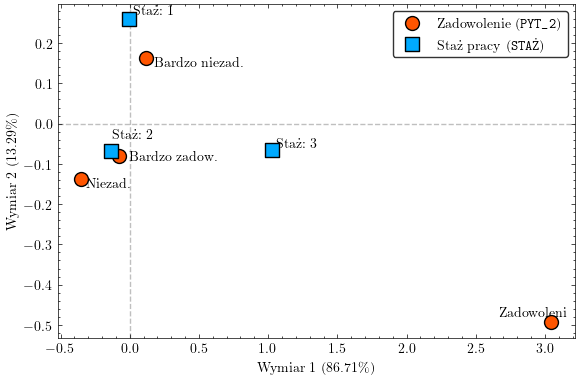

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

from adjustText import adjust_text
import scienceplots

sns.reset_orig()

plt.style.use(['default', 'science'])
plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage[T1]{fontenc} \usepackage{polski} \usepackage[utf8]{inputenc}'
})
figsize = (6, 4)
new_orange = '#ff5500'
inverse_orange = '#00aaff'

def analiza_korespondencji(tablica_dwudzielcza):
    X = tablica_dwudzielcza.values
    N = np.sum(X)
    P = X / N
    r = np.sum(P, axis=1)
    c = np.sum(P, axis=0)
    Dr_inv_sqrt = np.diag(1.0 / np.sqrt(r))
    Dc_inv_sqrt = np.diag(1.0 / np.sqrt(c))
    S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt
    U, Sigma, Vt = np.linalg.svd(S, full_matrices=False)
    wspolrzedne_wierszy = Dr_inv_sqrt @ U @ np.diag(Sigma)
    wspolrzedne_kolumn = Dc_inv_sqrt @ Vt.T @ np.diag(Sigma)
    inertia = Sigma**2
    procent_zmiennosci = (inertia / np.sum(inertia)) * 100
    df_wiersze = pd.DataFrame(wspolrzedne_wierszy, index=tablica_dwudzielcza.index,
                              columns=[f"Wymiar {i+1}" for i in range(len(Sigma))])
    df_kolumny = pd.DataFrame(wspolrzedne_kolumn, index=tablica_dwudzielcza.columns,
                              columns=[f"Wymiar {i+1}" for i in range(len(Sigma))])


    fig, ax = plt.subplots(figsize=figsize)
    pyt2_labels = {-2: 'Bardzo niezad.', -1: 'Niezad.', 1: 'Zadowoleni', 2: 'Bardzo zadow.'}

    texts_to_adjust = []

    ax.scatter(df_wiersze.iloc[:, 0], df_wiersze.iloc[:, 1],
               color=new_orange, edgecolor='black', marker='o', s=100,
               label=r'Zadowolenie (\texttt{PYT\_2})', zorder=5)

    for i, txt in enumerate(df_wiersze.index):
        label = pyt2_labels.get(txt, f"Opcja {txt}")
        t_obj = ax.text(df_wiersze.iloc[i, 0], df_wiersze.iloc[i, 1], label,
                         color='black', fontsize=10, weight='bold')
        texts_to_adjust.append(t_obj)

    ax.scatter(df_kolumny.iloc[:, 0], df_kolumny.iloc[:, 1],
               color=inverse_orange, edgecolor='black', marker='s', s=100,
               label=r'Staż pracy (\texttt{STAŻ})', zorder=5)

    for i, txt in enumerate(df_kolumny.index):
        t_obj = ax.text(df_kolumny.iloc[i, 0], df_kolumny.iloc[i, 1], f"Staż: {txt}",
                         color='black', fontsize=10, weight='bold')
        texts_to_adjust.append(t_obj)


    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

    adjust_text(texts_to_adjust,
                ax=ax)


    ax.set_xlabel(f'Wymiar 1 ({procent_zmiennosci[0]:.2f}\\%)')
    ax.set_ylabel(f'Wymiar 2 ({procent_zmiennosci[1]:.2f}\\%)')

    ax.legend(loc='upper right', frameon=True, edgecolor='black')

    plt.tight_layout()
    plt.savefig('analiza_korespondencji.pdf')
    plt.show()

    return {"Wiersze": df_wiersze, "Kolumny": df_kolumny, "Bezwladnosc": procent_zmiennosci}


dane = pd.read_csv('ankieta2.csv', sep=';')
dane = dane.rename(columns={'STAĮ': 'STAŻ', 'P£E∆': 'PŁEĆ'})
tab_krzyzowa = pd.crosstab(dane['PYT_2'], dane['STAŻ'])
wynik_ca = analiza_korespondencji(tab_krzyzowa)

# zadanie dodatkowe 1

In [36]:
def distance_correlation(X, Y):
    X = np.atleast_1d(X)
    Y = np.atleast_1d(Y)

    n = len(X)

    a = np.abs(X[:, None] - X[None, :])
    b = np.abs(Y[:, None] - Y[None, :])

    A = a - a.mean(axis=0)[None, :] - a.mean(axis=1)[:, None] + a.mean()
    B = b - b.mean(axis=0)[None, :] - b.mean(axis=1)[:, None] + b.mean()

    dcov2_xy = np.sum(A * B) / (n ** 2)
    dcov2_xx = np.sum(A * A) / (n ** 2)
    dcov2_yy = np.sum(B * B) / (n ** 2)

    if dcov2_xx > 0 and dcov2_yy > 0:
        dcor = np.sqrt(np.maximum(dcov2_xy, 0) / np.sqrt(dcov2_xx * dcov2_yy))
    else:
        dcor = 0.0

    return dcor


def dcor_test(X, Y, num_permutations=1000):
    """
    Wylicza p-value dla testu niezależności opartego na korelacji odległości.
    """
    obs_dcor = distance_correlation(X, Y)

    count_greater = 0
    Y_permuted = np.copy(Y)

    for _ in range(num_permutations):
        np.random.shuffle(Y_permuted)
        perm_dcor = distance_correlation(X, Y_permuted)

        if perm_dcor >= obs_dcor:
            count_greater += 1

    p_value = (count_greater + 1) / (num_permutations + 1)

    return obs_dcor, p_value


np.random.seed(42)  # dla powtarzalności wyników
n_samples = 100

print("=== SCENARIUSZ 1: Zmienne CAŁKOWICIE NIEZALEŻNE ===")
X_indep = np.random.normal(0, 1, n_samples)
Y_indep = np.random.normal(0, 1, n_samples)

dcor_val, p_val = dcor_test(X_indep, Y_indep)

print(f"Korelacja odległości: {dcor_val:.4f}")
print(f"p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Wniosek: Odrzucamy H0 (Są zależne!)")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0)")

print("\n=== SCENARIUSZ 2: Zmienne ZALEŻNE NIELINIOWO (Parabola) ===")
X_dep = np.random.uniform(-3, 3, n_samples)
Y_dep = X_dep ** 2 + np.random.normal(0, 0.5, n_samples)

dcor_val2, p_val2 = dcor_test(X_dep, Y_dep)

print(f"Korelacja odległości: {dcor_val2:.4f}")
print(f"p-value: {p_val2:.4f}")

if p_val2 < 0.05:
    print("Wniosek: Odrzucamy H0")
else:
    print("Wniosek: Brak podstaw do odrzucenia H0.")

=== SCENARIUSZ 1: Zmienne CAŁKOWICIE NIEZALEŻNE ===
Korelacja odległości: 0.1903
p-value: 0.2507
Wniosek: Brak podstaw do odrzucenia H0)

=== SCENARIUSZ 2: Zmienne ZALEŻNE NIELINIOWO (Parabola) ===
Korelacja odległości: 0.5061
p-value: 0.0010
Wniosek: Odrzucamy H0


## Zadanie *2
Dla zadanych $\pi_1$ oraz $\pi_2$ pokaż, że wartość ryzyka względnego (RR) nie jest bardziej oddalona od wartości 1 (wartość odpowiadająca niezależności) niż wartość odpowiadającego ilorazu szans (OR).

In [37]:
import numpy as np

# 1. Wygenerowanie siatki prawdopodobieństw (0.01 do 0.99)
pi_1 = np.linspace(0.01, 0.99, 100)
pi_2 = np.linspace(0.01, 0.99, 100)

# Stworzenie siatki kombinacji wszystkich wartości
PI1, PI2 = np.meshgrid(pi_1, pi_2)

# 2. Obliczenie Ryzyka Względnego (RR)
RR = PI1 / PI2

# 3. Obliczenie Ilorazu Szans (OR)
odds1 = PI1 / (1 - PI1)
odds2 = PI2 / (1 - PI2)
OR = odds1 / odds2

# 4. Obliczenie odległości od wartości 1 (niezależność)
dist_RR = np.abs(RR - 1)
dist_OR = np.abs(OR - 1)

# 5. Weryfikacja warunku: czy odległość RR jest zawsze mniejsza lub równa odległości OR?
# Używamy np.isclose do wyłapania ewentualnych błędów precyzji zmiennoprzecinkowej dla równych wartości
condition_met = np.all((dist_RR <= dist_OR) | np.isclose(dist_RR, dist_OR))

print(f"TEZA: Wartość RR nie jest bardziej oddalona od 1 niż OR.")
print(f"WYNIK SYMULACJI: {'Potwierdzona' if condition_met else 'Obalona'}\n")

# Wyświetlenie kilku przykładowych punktów do zobrazowania problemu
print("Przykładowe wartości obliczone przez skrypt:")
print("-" * 75)
sample_indices = [(20, 10), (50, 50), (40, 80)] # Indeksy z wygenerowanej macierzy

for i, j in sample_indices:
    p1, p2 = PI1[i, j], PI2[i, j]
    r, o = RR[i, j], OR[i, j]
    print(f"pi_1 = {p1:.2f}, pi_2 = {p2:.2f} | RR = {r:.3f}, OR = {o:.3f}")
    print(f"Odległość RR od 1: {abs(r-1):.3f} | Odległość OR od 1: {abs(o-1):.3f}")
    print("-" * 75)

TEZA: Wartość RR nie jest bardziej oddalona od 1 niż OR.
WYNIK SYMULACJI: Potwierdzona

Przykładowe wartości obliczone przez skrypt:
---------------------------------------------------------------------------
pi_1 = 0.11, pi_2 = 0.21 | RR = 0.524, OR = 0.466
Odległość RR od 1: 0.476 | Odległość OR od 1: 0.534
---------------------------------------------------------------------------
pi_1 = 0.50, pi_2 = 0.50 | RR = 1.000, OR = 1.000
Odległość RR od 1: 0.000 | Odległość OR od 1: 0.000
---------------------------------------------------------------------------
pi_1 = 0.80, pi_2 = 0.41 | RR = 1.975, OR = 5.924
Odległość RR od 1: 0.975 | Odległość OR od 1: 4.924
---------------------------------------------------------------------------


# Zadanie *3(b)
Niech $D$ oznacza posiadanie pewnej choroby, a $E$ pozostawanie wystawionym na pewny czynnik ryzyka. W badaniach epidemiologicznych definuje się miarę $AR$ nazywaną ryzykiem przypisanym (ang. $\textit{attributable risk}$).

(b) Pokaż, że AR ma związek z ryzykiem względnym, tzn.: $AR = \frac{P(E)(RR - 1)}{1 + P(E)(RR - 1)}$

In [38]:
import numpy as np

# 1. Wygenerowanie siatek prawdopodobieństw (od 0.01 do 0.99, po 100 wartości)
p_E_vals = np.linspace(0.01, 0.99, 100)
p_D_given_E_vals = np.linspace(0.01, 0.99, 100)
p_D_given_not_E_vals = np.linspace(0.01, 0.99, 100)

# Stworzenie trójwymiarowej siatki kombinacji wszystkich wartości (1 000 000 kombinacji)
P_E, P_D_given_E, P_D_given_not_E = np.meshgrid(p_E_vals, p_D_given_E_vals, p_D_given_not_E_vals)

# 2. Obliczenie P(D) z Prawa Całkowitego Prawdopodobieństwa
# P(D) = P(D|E)*P(E) + P(D|E')*P(E')
P_D = (P_D_given_E * P_E) + (P_D_given_not_E * (1 - P_E))

# 3. Obliczenie RR i klasycznego AR
RR = P_D_given_E / P_D_given_not_E
AR_classic = (P_D - P_D_given_not_E) / P_D

# 4. Obliczenie AR ze wzoru z podpunktu (b)
AR_transformed = (P_E * (RR - 1)) / (1 + P_E * (RR - 1))

# 5. Weryfikacja: czy oba wzory dają ten sam wynik?
condition_met = np.allclose(AR_classic, AR_transformed)

print(f"TEZA: Wzór klasyczny i przekształcony dają identyczne wyniki.")
print(f"WYNIK SYMULACJI: {'Potwierdzona' if condition_met else 'Obalona'}\n")

# Wyświetlenie kilku przykładowych punktów
print("Przykładowe wartości obliczone przez skrypt:")
print("-" * 75)
sample_indices = [(10, 50, 20), (50, 80, 40), (90, 30, 70)]

for i, j, k in sample_indices:
    pe = P_E[i, j, k]
    pd_e = P_D_given_E[i, j, k]
    pd_ne = P_D_given_not_E[i, j, k]
    ar_c = AR_classic[i, j, k]
    ar_t = AR_transformed[i, j, k]

    print(f"P(E) = {pe:.2f}, P(D|E) = {pd_e:.2f}, P(D|E') = {pd_ne:.2f}")
    print(f"AR (definicja): {ar_c:.5f} | AR (nowy wzór): {ar_t:.5f}")
    print("-" * 75)

TEZA: Wzór klasyczny i przekształcony dają identyczne wyniki.
WYNIK SYMULACJI: Potwierdzona

Przykładowe wartości obliczone przez skrypt:
---------------------------------------------------------------------------
P(E) = 0.50, P(D|E) = 0.11, P(D|E') = 0.21
AR (definicja): -0.31637 | AR (nowy wzór): -0.31637
---------------------------------------------------------------------------
P(E) = 0.80, P(D|E) = 0.50, P(D|E') = 0.41
AR (definicja): 0.16356 | AR (nowy wzór): 0.16356
---------------------------------------------------------------------------
P(E) = 0.31, P(D|E) = 0.90, P(D|E') = 0.70
AR (definicja): 0.07958 | AR (nowy wzór): 0.07958
---------------------------------------------------------------------------
